# Single Particle Tracking simulator

In [1]:
import helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *

In [2]:
%reload_ext autoreload
%autoreload 2

## 1. Particles simulator

Generate frames with moving particles following normal diffusion (Brownian motion)

In [4]:
F = 20
N = 15
frames, trajectories_GT, D_GT = generate_frames_random(F, N, D=None, amp = 2000, noise_gaussian=True, noise_poisson=True)

Frame 0
Frame 10
Trajectory 4 cropped at end by 5 frames
Trajectory 9 cropped at end by 6 frames
Trajectory 12 cropped at end by 1 frames


In [5]:
viewer = view_frames(frames)
viewer

In [6]:
check_min_max(frames[0])

min: 0.0
max: 2113.5609075040925


-> can see gaussian noise very well when zooming in saved picture.  

## 2. Diffusion coefficients estimation

### 2.0 $ D_{GT} $

In [7]:
print('D_GT =', D_GT)

D_GT = [4, 0, 3, 0, 0, 4, 0, 0, 3, 1, 0, 0, 0, 1, 3]


### 2.1 $ D_{trajectory} $

In [8]:
calculate_msd_trajectories(trajectories_GT)

In [9]:
D_trajectory = estimateDfromTrajectories_safer(trajectories_GT)
print(f"D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in D_trajectory)}]")

D_trajectory: 
[2.306, -0.000, 1.264, -0.000, -0.000, 1.490, -0.000, -0.000, 0.634, 0.170, -0.000, -0.000, -0.000, 0.689, 0.871]


In [10]:
MAE_trajectory = np.abs(np.array(D_trajectory) - np.array(D_GT))
print(f"MAE for D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in MAE_trajectory)}]")

MAE for D_trajectory: 
[1.694, 0.000, 1.736, 0.000, 0.000, 2.510, 0.000, 0.000, 2.366, 0.830, 0.000, 0.000, 0.000, 0.311, 2.129]


*=> D of 0 is perfectly estimated*

### 2.2 $ D_{detection} $

Detection followed by Local Nearest Neighbor tracking

In [11]:
detected_peaks = detect_peaks(frames)

In [12]:
trajectories_detection = NN_tracking_enchanced(detected_peaks, max_distance=5)

print("Number of trajectories:", len(trajectories_detection))
print("Sizes of trajectories:", [len(traj.get_positions()) for traj in trajectories_detection])

Number of trajectories: 19
Sizes of trajectories: [20, 20, 20, 20, 2, 20, 4, 20, 2, 20, 20, 20, 20, 9, 20, 4, 15, 6, 9]


### Assignment of detected trajectories to GT trajectories

In [13]:
# assignment using the Hungarian algorithm
trajectories_detection, min_cost, assignment_detection = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[9.04185223e+01 4.60283023e+01 4.60374298e+01 1.01139145e+01
  5.20667485e+01 1.00077426e+02 6.13988346e+01 8.43567713e+01
  1.73284669e+01 1.19560679e-01 3.53715683e+01 2.79936813e-01
  5.21551679e+01 3.68074452e+01 6.60224104e+01]
 [2.91696081e+01 5.51292890e+01 3.98678161e+01 7.14709269e+01
  1.01668494e+02 9.98413760e+01 2.90004448e-01 1.34490841e+02
  5.10736073e+01 6.13115086e+01 6.88662688e+01 6.16640510e+01
  2.43541008e+01 9.55276205e+01 5.12152049e+00]
 [1.24370079e+02 5.98002588e+01 8.21794215e+01 2.88442538e+01
  2.42182619e+01 1.00301438e+02 9.51732578e+01 5.07193569e+01
  5.33337046e+01 3.66558676e+01 3.89036586e+01 3.64332466e+01
  8.86661726e+01 3.81984068e-01 9.93617544e+01]
 [7.91658373e+01 5.37122893e+01 2.89647056e+01 2.46550490e+01
  6.92797300e+01 1.09570897e+02 5.13784218e+01 1.01625793e+02
  2.51957469e-01 1.72599011e+01 4.89272381e+01 1.73645243e+01
  3.71232004e+01 5.33937884e+01 5.63285890e+01]
 [1.13336184e+02 5.45346980e+01 1.23467191e+02 1.03

In [14]:
# pypi algo not functional on rectangular cost matrix
#trajectories_detection_pypi, assignment_pypi = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian_pypi')

In [15]:
# compare_assignments(assignment, assignment_pypi)

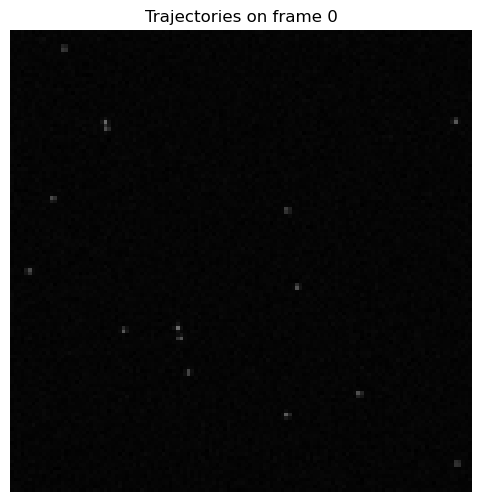

In [18]:
show_trajectories(frames, trajectories_detection, frame_id=0)

In [19]:
calculate_msd_trajectories(trajectories_detection)

In [20]:
D_detection = estimateDfromTrajectories_safer(trajectories_detection)
print(f"D_detection: \n[{', '.join(f'{float(d):.3f}' for d in D_detection)}]")

D_detection: 
[0.111, 0.026, 0.752, 0.826, 5.000, -0.000, -0.000, -0.000, 1.000, -0.000, 0.748, 0.007, -0.000, 0.660, -0.000, 0.917, 1.352, 5.161, 1.544]


In [21]:
# calculate MAE for D_detection
MAE_detection = compute_MAE_detection(trajectories_detection, D_GT)

D_detection:
['0.660', '-0.000', '0.748', '0.007', '-0.000', '5.000', '0.026', '-0.000', '0.826', '0.111', '-0.000', '-0.000', '-0.000', '0.752', '1.352']
MAE for D_detection:
['3.340', '0.000', '2.252', '0.007', '0.000', '1.000', '0.026', '0.000', '2.174', '0.889', '0.000', '0.000', '0.000', '0.248', '1.648']


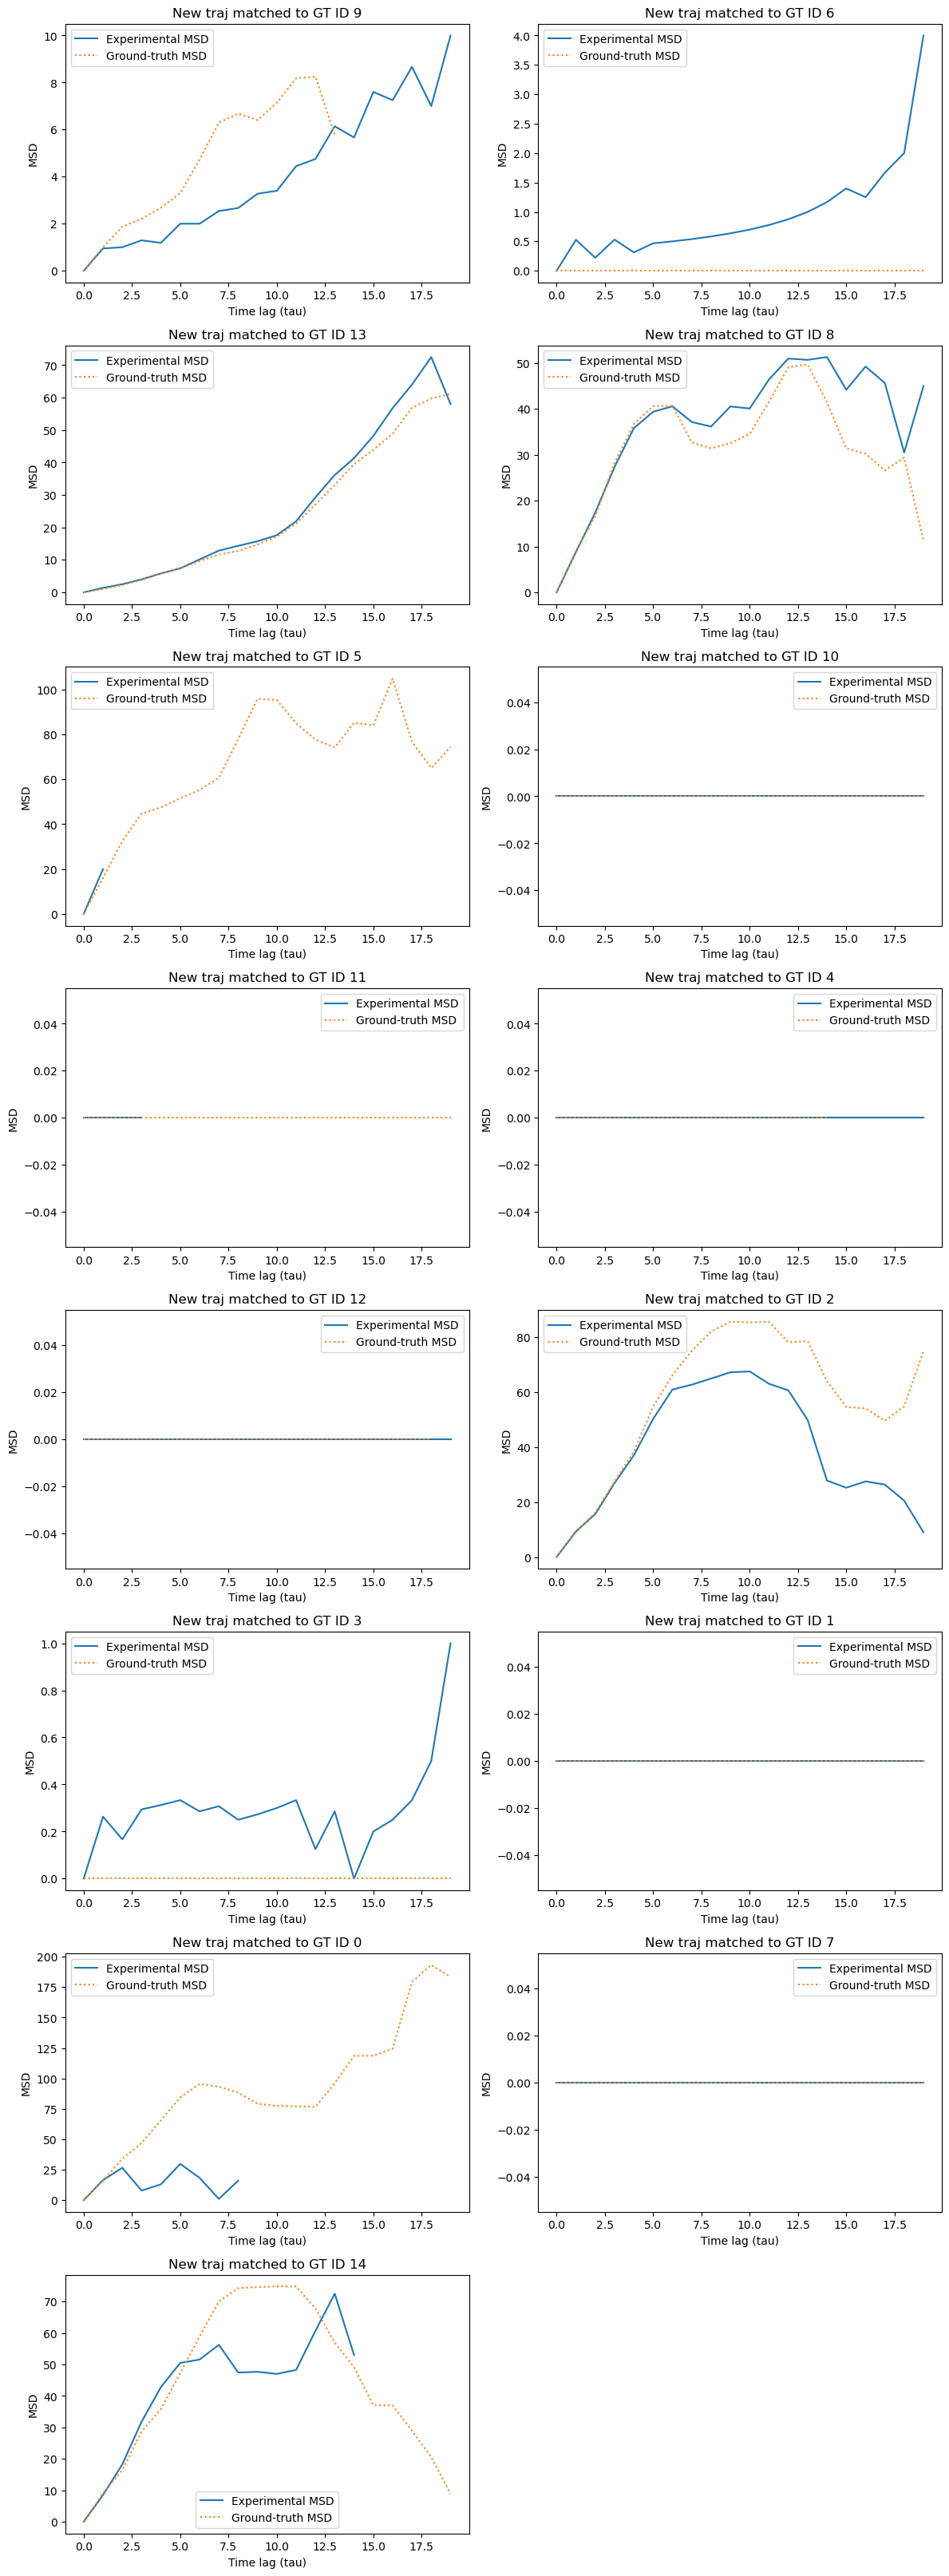

In [22]:
plot_msd_vs_trajectory_msd(trajectories_detection, trajectories_GT)

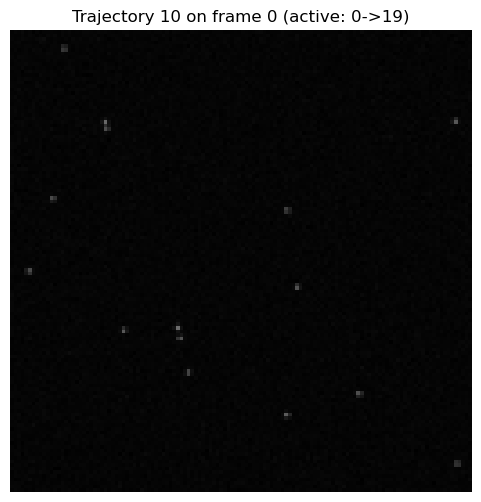

In [23]:
show_trajectory(frames, trajectories_detection, traj_id=10)

### 3.3 $ D_{localization} $

By Gaussian fitting

Fitted center for peak at (82, 46): (81.99, 45.98), amplitude 1990.89, sigma 0.48


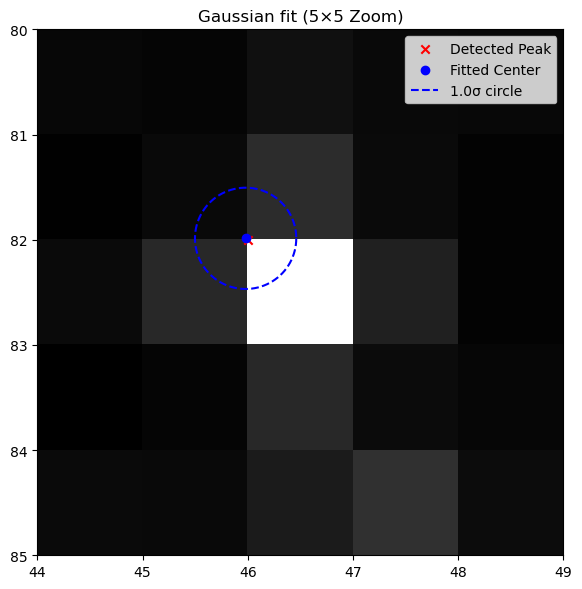

Fitted center for peak at (25, 26): (25.32, 26.01), amplitude 2317.69, sigma 0.45
Fitted center for peak at (106, 76): (106.13, 76.24), amplitude 1947.56, sigma 0.51
Fitted center for peak at (83, 31): (82.69, 31.13), amplitude 2016.27, sigma 0.51
Fitted center for peak at (25, 123): (24.72, 122.90), amplitude 1929.21, sigma 0.49
Fitted center for peak at (71, 79): (70.64, 79.15), amplitude 2143.83, sigma 0.46
Fitted center for peak at (85, 47): (84.85, 46.61), amplitude 2175.31, sigma 0.47
Fitted center for peak at (100, 96): (100.29, 96.32), amplitude 2102.89, sigma 0.48
Fitted center for peak at (27, 26): (25.32, 26.01), amplitude 2343.26, sigma 0.45
Fitted center for peak at (46, 11): (46.30, 11.42), amplitude 2838.29, sigma 0.42
Fitted center for peak at (66, 5): (66.38, 4.82), amplitude 1808.64, sigma 0.53
Fitted center for peak at (94, 49): (94.49, 49.00), amplitude 1924.93, sigma 0.51
Fitted center for peak at (49, 76): (49.45, 76.32), amplitude 1970.66, sigma 0.50
Fitted cente

In [24]:
# 1min50 rutime for 100 frames
localized_peaks = localize_peaks_with_gaussian_fitting(frames, detected_peaks, verbose=True, visualization=True)

In [25]:
# should be able to pick up trajs that start after first frame!
trajectories_localization = NN_tracking_enchanced(localized_peaks, max_distance=5)

In [26]:
print("Number of localized trajectories:", len(trajectories_localization))

Number of localized trajectories: 22


In [27]:
# assignment using the Hungarian algorithm
trajectories_localization, min_cost,assignment_localization = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[8.97360896e+01 4.57585820e+01 4.54702824e+01 1.07821090e+01
  5.25423226e+01 9.99441619e+01 6.07195109e+01 8.48875509e+01
  1.68091869e+01 6.01817215e-01 3.54138398e+01 9.36020147e-01
  5.14985722e+01 3.74467900e+01 6.53459204e+01]
 [2.91227004e+01 5.49520504e+01 4.01806448e+01 7.15690371e+01
  1.01616104e+02 9.95498569e+01 1.12107950e-01 1.34422235e+02
  5.12465370e+01 6.14042302e+01 6.87742574e+01 6.17577703e+01
  2.46853203e+01 9.55586928e+01 4.89503578e+00]
 [1.24485320e+02 5.98780568e+01 8.23000602e+01 2.89633248e+01
  2.41648389e+01 1.00324534e+02 9.52888859e+01 5.06146109e+01
  5.34545652e+01 3.67773724e+01 3.89722347e+01 3.65547485e+01
  8.87875033e+01 3.33791544e-01 9.94762836e+01]
 [7.91039759e+01 5.36716688e+01 2.89342553e+01 2.46936245e+01
  6.92939830e+01 1.09532255e+02 5.13141060e+01 1.01645931e+02
  1.86648589e-01 1.72784090e+01 4.89105002e+01 1.73844205e+01
  3.70713927e+01 5.34266759e+01 5.62640999e+01]
 [1.13230982e+02 5.44533108e+01 1.23374767e+02 1.03

In [28]:
calculate_msd_trajectories(trajectories_localization)

In [29]:
print(len(trajectories_localization))

22


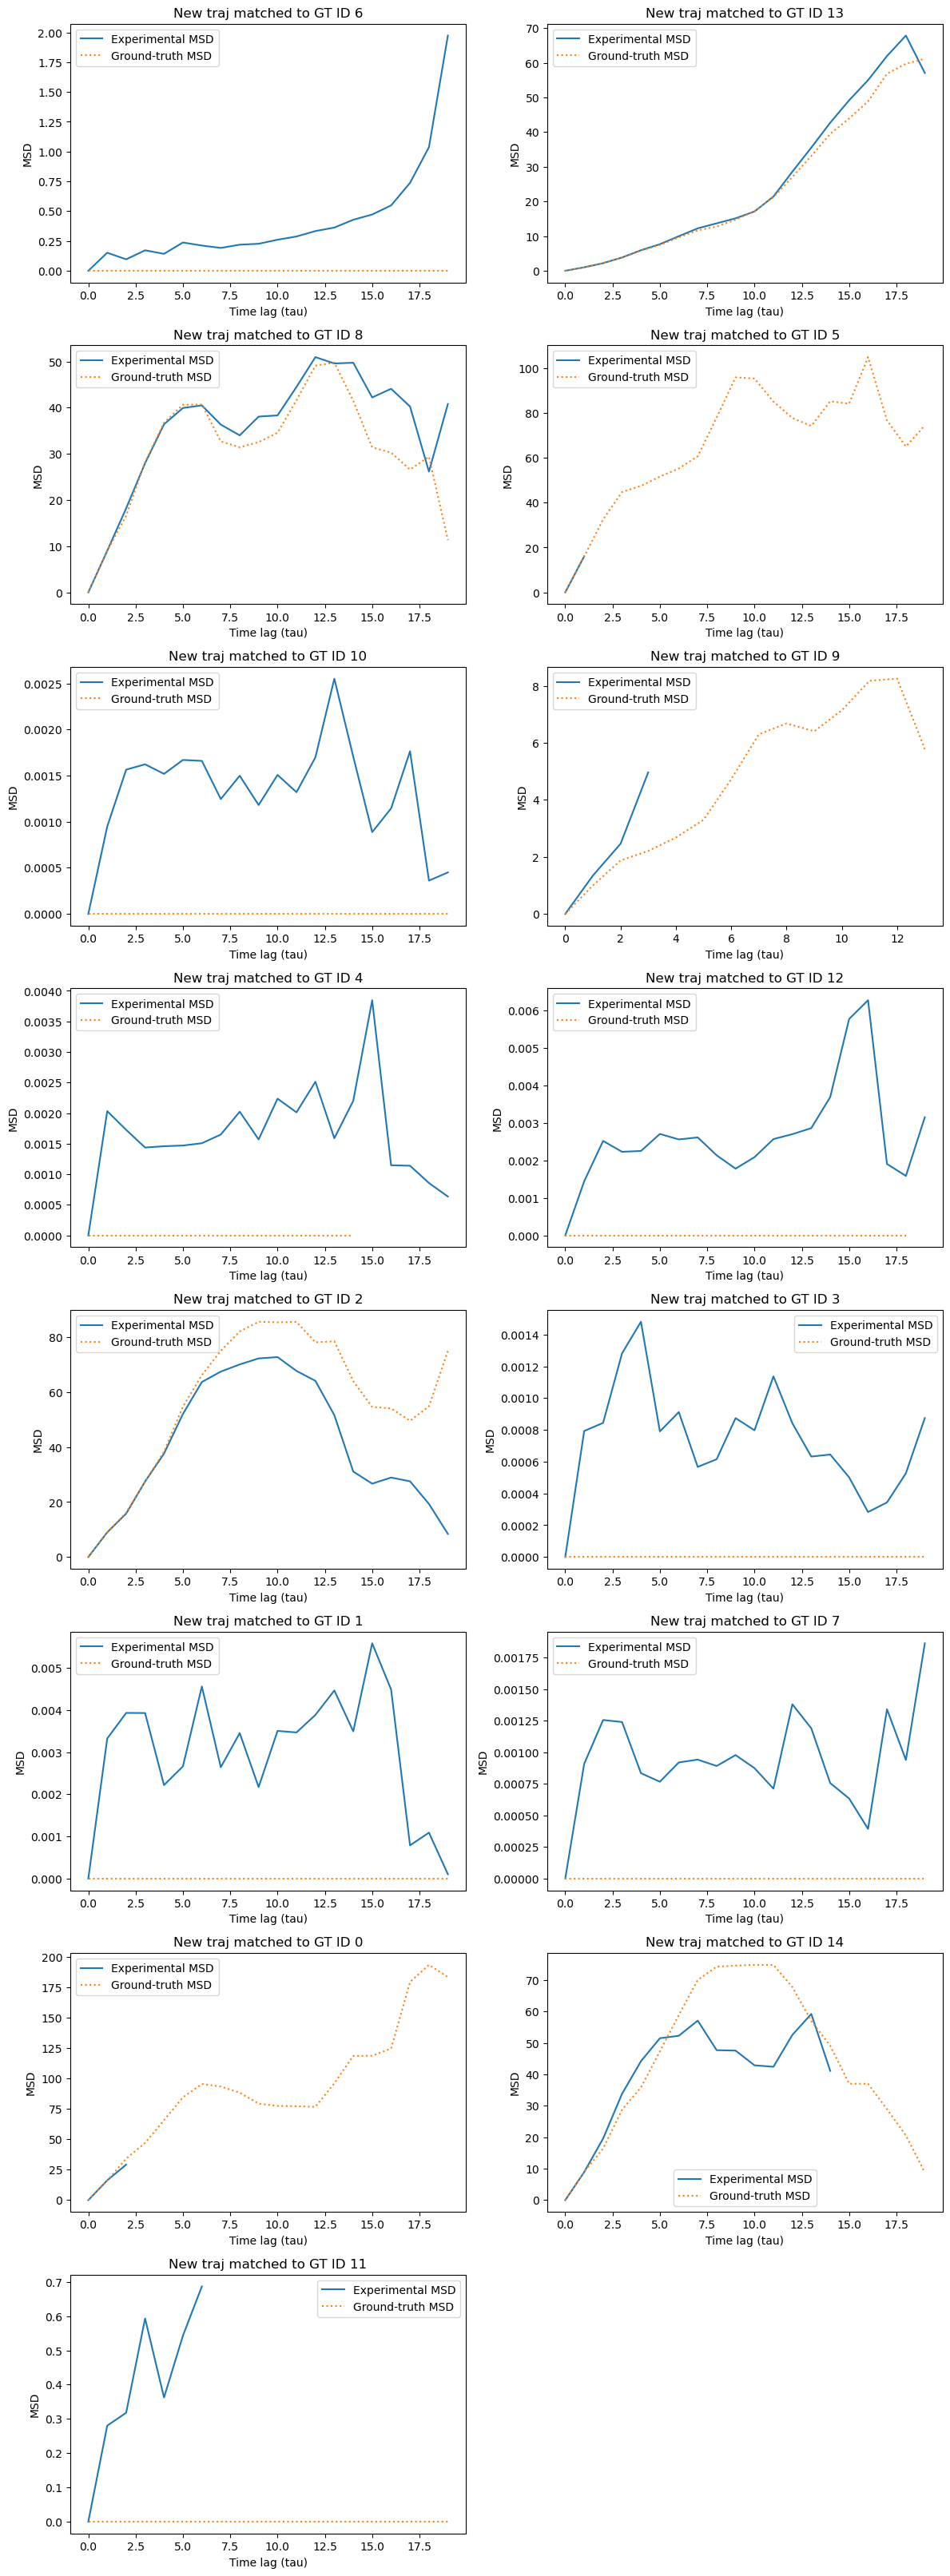

In [30]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

In [31]:
D_localization = estimateDfromTrajectories(trajectories_localization)
print(f"D_localization: \n[{', '.join(f'{float(d):.3f}' for d in D_localization)}]")

D_localization: 
[0.231, 0.012, 0.734, 0.777, 4.019, 0.000, 0.378, 0.000, 1.932, 0.000, 0.788, 0.000, 0.000, 0.000, 1.057, 3.728, 1.226, 0.028, 3.923, 4.000, 0.030, 2.884]


In [32]:
# calculate MAE for D_localization
MAE = {}
for traj in trajectories_localization:
    MAE[traj.id] = compute_MAE(traj.D_localization, traj.D_trajectory)
print("MAE for D_localization:")
for traj_id, mae in MAE.items():
    if traj_id is not None and traj_id is not -1:
        print(f"{traj_id}: {mae:.3f}")

MAE for D_localization:
-1: 2.884
6: 0.012
13: 0.734
8: 0.777
5: 4.019
10: 0.000
9: 0.378
4: 0.000
12: 0.000
2: 0.788
3: 0.000
1: 0.000
7: 0.000
0: 3.728
14: 1.226
11: 0.030


<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\armel\AppData\Local\Temp\ipykernel_39508\474422645.py:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if traj_id is not None and traj_id is not -1:


### Linear trajectories visualization

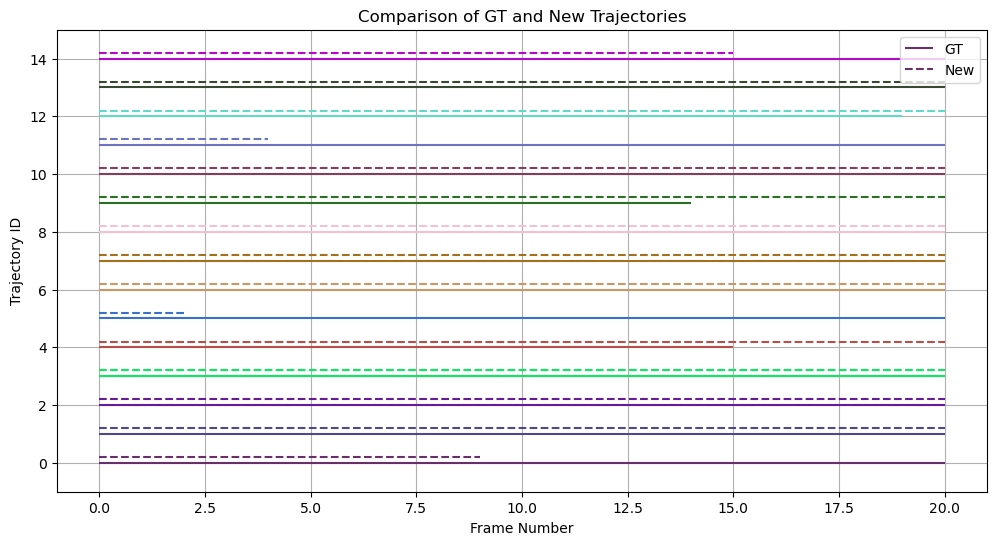

In [33]:
linear_trajectories_visualizer(trajectories_detection, trajectories_GT)

-> start cropping not functional: just crops and moves remaining positions towards 0

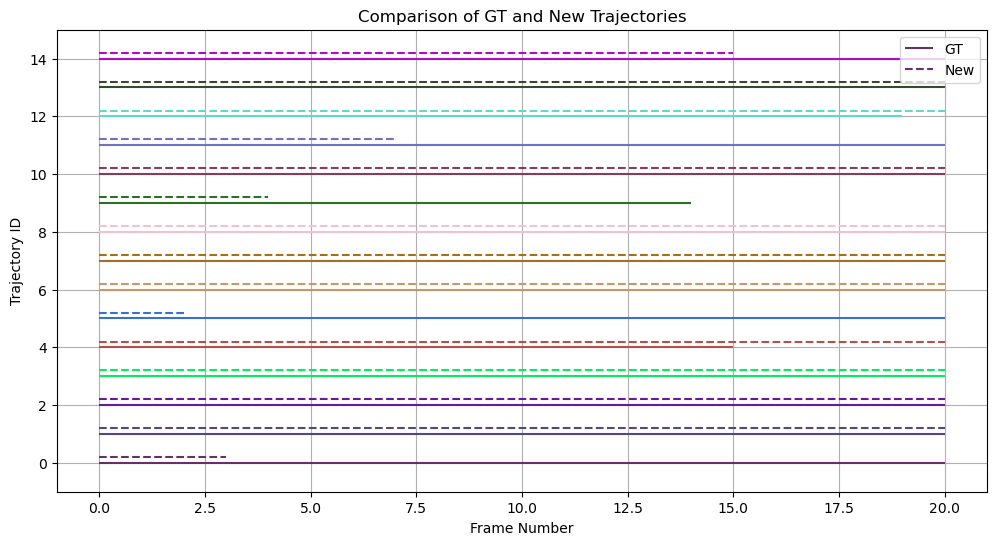

In [34]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)